---
# Instructions pour quarto
title: ""
format:
  html:
    code-fold: true
    embed-resources: true
  
---

<!-- Header stylé -->
<div style="background: linear-gradient(90deg, #4e54c8, #8f94fb); padding: 30px; border-radius: 12px; color: white; text-align: center; margin-bottom: 20px;">
  <h3 style="margin: 0; font-size: 3em;">🏠🚆Lien entre l'offre de transport et le prix du logement en Île-de-France 🏠🚆</h3>
</div>

# Introduction

L'objectif de ce projet est d'analyser comment l'accessibilité aux transports en commun influence le prix du logement en Île‑de‑France. Pour cela nous croisons deux sources principales : 

- les transactions immobilières obtenues via la base de donnée DVF ("Demande de valeur foncière") pour obtenir les prix et la localisation des logements
- les données issues de l'API IDFM (Île-de-France Mobilité) décrivant les horaires prévus des transports en commun dans les 30 prochains jours.

Des données INSEE sont également utilisées pour compléter l'analyse.

Les traitements effectués sont les suivants :

1. Une première phase d'ingestion, nettoyage et visualisation est effectuée séparément chaque base de donnée. Ces phases son présentées dans des pages séparées : [Traitement de IDFM](idfm.html) et [Traitement de DVF](dvf.html)

2. La version nettoyée de DVF est ensuite augmentée d'informations sur 
- la desserte en transport du logement
- la distance au centre de Paris
- le niveau de vie dans la commune

3. Nous adoptons ensuite une approche économétrique afin de modéliser l’impact des infrastructures de transport sur les prix immobiliers

Un modèle de prédiction du prix du logement via une méthode non-paramétrique est également entraîné. Les résultats sont présentés dans la partie [prédiction](ml.html).

# Ajout de la desserte à DVF

L'approche retenue et d'ajouter au dataframe DVF des métriques indiquant la desserte en transport de chaque logement vendu.


## Calcul des arrêts les plus proches

Après avoir ouvert les fichiers intermédiaires, on ajoute à chaque logement la distance à l'arrêt le plus proche pour chaque mode de transport (train, metro, tramway, bus).

Les première lignes du dataframe obtenues sont affichées pour illustrer (seules les colonnes nouvellement ajoutées sont affichées).

In [1]:
import os
import geopandas as gpd

# verifie que l'exectution se fait depuis le bon répertoire
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# ouverture des fichiers geojson
gdf_idfm_small = gpd.read_file("cache/results/passage_par_arret_synthetique.geojson")
gdf_idfm = gpd.read_file("cache/results/passage_par_arret_full.geojson")
gdf_dvf = gpd.read_file("cache/results/prix_logements.geojson")

# ajout d'une cle principale à gdf_dvf
gdf_dvf['point_id'] = gdf_dvf.index.astype(str)


# reprojeter en CRS métrique, trouver le point le plus proche et la distance en mètres
gdf_dvf_m = gdf_dvf.to_crs(epsg=3857)
gdf_idfm_small_m = gdf_idfm_small.to_crs(epsg=3857)
gdf_idfm_m = gdf_idfm.to_crs(epsg=3857)

for target in ["bus", "metro", "tramway", "train"]:
    target_df = gdf_idfm_small_m[gdf_idfm_small_m[f"nb_{target}_per_day"] > 0]

    nearest = gpd.sjoin_nearest(
        gdf_dvf_m,
        target_df[['stop_id', 'geometry']],
        how='left',
        distance_col='dist_m'
    )

    # ajouter résultats (distance en m et km, id du stop le plus proche) au GeoDataFrame original
    nearest = nearest.reset_index(drop=True)

    gdf_dvf[f"nearest_{target}_stop_id"] = nearest['stop_id']
    gdf_dvf[f"nearest_{target}_dist_m"] = nearest['dist_m']

# afficher le résultat
gdf_dvf[['adresse', 'nearest_bus_stop_id', 'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m', 'nearest_tramway_stop_id', 'nearest_tramway_dist_m', 'nearest_train_stop_id', 'nearest_train_dist_m']].head()

,adresse,nearest_bus_stop_id,nearest_bus_dist_m,nearest_metro_stop_id,nearest_metro_dist_m,nearest_tramway_stop_id,nearest_tramway_dist_m,nearest_train_stop_id,nearest_train_dist_m
0,1 ALL ADRIENNE,IDFM:73300,155.389997,IDFM:426280,3222.044283,IDFM:73312,708.300133,IDFM:73297,810.600601
1,1 ALL ANDRE MALRAUX,IDFM:74261,264.083932,IDFM:69884,71707.338011,IDFM:68293,52890.886380,IDFM:62168,1451.228854
2,1 ALL ANDRE MALRAUX,IDFM:65153,251.057114,IDFM:71517,22369.191978,IDFM:480927,6986.766072,IDFM:73604,3325.780821
3,1 ALL ANTOINE GROSSIN,IDFM:70505,261.182603,IDFM:70671,2109.592489,IDFM:70310,2226.866100,IDFM:70505,261.182603
4,1 ALL ARAGON,IDFM:73498,154.031537,IDFM:426280,15289.094394,IDFM:73411,7031.585384,IDFM:73482,1142.816999


--

## Calcul de l'offre de transport dans un rayon de 1km 

- **Objectif :** pour chaque point de DVF, compter et agréger l'offre de transport présente dans un rayon de 1 km.
- **Étapes :** 
    - on crée un disque de rayon 1 km autour de chaque logement.
    - on effectue une jointure spatiale pour obtenir tous les couples arrêt situés à ≤ 1 km.
    - dans chauque disque aggrège par ligne de transport (*"route"*) puis par mode (*"route_type"*) pour obtenir le nombre de passage de transport en commun par jour et par mode autour de chaque logement. L'aggrègation d'abord par ligne permet d'éviter de compter plusieurs fois un moyen de transport qui s'arrête plusieurs fois autour d'un logment.
    - après quelques étapes supplémentaires (pivot, renommage, filtrage), les résultats sont ajoutés à DVF

In [2]:
radius_m = 1000 # Distance seuil

# Créer des buffers (disques) de rayon 1 km autour de chaque point DVF
# Utilise gdf_dvf_m (déjà en CRS métrique) pour créer les buffers
gdf_dvf_buffers = gdf_dvf_m.copy()
gdf_dvf_buffers['geometry'] = gdf_dvf_m.geometry.buffer(radius_m)

# Jointure spatiale : trouver tous les couples (point DVF, arrêt de transport) où l'arrêt intersecte le buffer du point
joined = gpd.sjoin(
    gdf_dvf_buffers[['point_id', 'geometry']], 
    gdf_idfm_m[['stop_id', 'route_id', 'nb_stops_per_day', 'route_type', 'geometry']], 
    how='left',  # Jointure gauche pour garder tous les points DVF, même sans intersections
    predicate='intersects' 
).drop(columns=['index_right', 'geometry']).reset_index(drop=True) # Supprimer les colonnes inutiles après jointure


# Agrégation première : par point_id, route_id et route_type, prendre le max de nb_stops_per_day par route
# Cela évite de compter plusieurs fois une route qui passe par plusieurs arrêts dans le rayon
grouped = joined.groupby(
    ['point_id', 'route_id', 'route_type'],
    dropna=False,  # Garder les groupes avec NaN
    as_index=False
).agg(
    nb_stops_per_day_route=('nb_stops_per_day', 'max')  # Max passages par route
).reset_index(drop=True)

# Agrégation seconde : par point_id et route_type, sommer les passages, compter les routes et stations uniques
grouped2 = joined.groupby(['point_id', 'route_type'],
    dropna=False,
    as_index=False).agg(
    passage_journalier=('nb_stops_per_day', 'sum'),  # Somme des passages journaliers par mode
    nb_routes=('route_id', 'nunique'),  # Nombre de routes uniques par mode
    nb_stations=('stop_id', 'nunique')  # Nombre de stations uniques par mode
).reset_index(drop=True)

# Pivot de grouped2 pour avoir une colonne par mode de transport (route_type)
# Les valeurs sont passage_journalier, nb_routes, nb_stations pour chaque mode
grouped2_pivot = grouped2.pivot_table(
    index='point_id',
    columns='route_type', 
    values=['passage_journalier', 'nb_routes', 'nb_stations'],  
    dropna=False,  # Garder les NaN
    fill_value=0  # Remplir les valeurs manquantes par 0 (aucun passage/routes/stations)
)

# Renommer les colonnes pour mapper les codes route_type aux noms de modes
grouped2_pivot = grouped2_pivot.rename(columns={
    0: "tramway",  # 0 -> tramway
    1: "metro",   # 1 -> metro
    2: "train",   # 2 -> train
    3: "bus",     # 3 -> bus
    6: "IGNORED", # 6 -> ignoré (autres modes)
    7: "IGNORED"  # 7 -> ignoré (autres modes)
})

# Aplatir les colonnes multi-index
grouped2_pivot.columns = [
    f"{name}_{mode}_1km"  # Format : passage_journalier_tramway_1km
    for name, mode in grouped2_pivot.columns
]

# Réinitialiser l'index pour avoir point_id comme colonne
grouped2_pivot = grouped2_pivot.reset_index()

# Supprimer les colonnes contenant '_nan_' ou 'IGNORED' (modes non pertinents)
grouped2_pivot = grouped2_pivot.loc[:, ~(grouped2_pivot.columns.str.contains('_nan_') | grouped2_pivot.columns.str.contains('IGNORED'))]

# Fusionner les résultats agrégés dans gdf_dvf pour créer gdf_dvf_final
gdf_dvf_final = gdf_dvf.merge(
    grouped2_pivot,
    on='point_id',  
    how='left'
)



Pour illustre les données obtenues, on affiche le premier point de DVF. La carte interactive montre :
- Un marqueur bleu pour le point DVF.
- Des marqueurs rouges pour les arrêts de transport à moins de 1 km (avec passages journaliers agrégés par mode).
- Des marqueurs verts pour les arrêts les plus proches par mode de transport (bus, métro, tramway, train), avec distances en mètres.

In [3]:
from branca.element import Template, MacroElement
from script.leaflet_tools import FondCarteLeaflet
import folium
import great_tables as gt


# affichage des stops within radius on a map for the first point only
df = joined

m = FondCarteLeaflet(afficher_grande_couronne=True).get_map()

first_point = gdf_dvf.iloc[0]
folium.CircleMarker(
    location=[first_point.geometry.y, first_point.geometry.x],
    popup=first_point['point_id'],
    color='blue'
).add_to(m)
for _, row in df[df['point_id'] == first_point['point_id']].iterrows():
    stop = gdf_idfm_small[gdf_idfm_small['stop_id'] == row['stop_id']]

    stop0 = stop.iloc[0]
    route_name = stop0.get('stop_name', None)

    folium.Marker(
        location=[stop0.geometry.y, stop0.geometry.x],
        tooltip=f"Nearby stop:\n{route_name}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

m

for target in ["bus", "metro", "tramway", "train"]:
    stop_id = first_point.get(f"nearest_{target}_stop_id")
    stop = gdf_idfm_small[gdf_idfm_small['stop_id'] == stop_id]

    stop0 = stop.iloc[0]
    route_name = stop0.get('stop_name', None)

    folium.Marker(
        location=[stop0.geometry.y, stop0.geometry.x],
        tooltip=f"Nearest {target} stop:\n{route_name}",
        icon=folium.Icon(color='green', icon='info-sign')
    ).add_to(m)

# add legend once (do not recreate inside the loop)
legend_html = """
{% macro html(this, kwargs) %}
<div style="position: fixed; 
    bottom: 50px; left: 50px; width: 220px; padding:8px;
    border:2px solid grey; z-index:9999; font-size:14px;
    background-color:white; box-shadow:2px 2px 6px rgba(0,0,0,0.15);
    ">
  <b>Legend</b><br>
  <span style="display:inline-block;width:12px;height:12px;background:blue;border-radius:50%;margin-right:8px;vertical-align:middle;"></span>
    Point (DVF sample)<br>
  <span style="display:inline-block;width:12px;height:12px;background:red;border-radius:3px;margin-right:8px;vertical-align:middle;"></span>
    Nearby stop (within radius)<br>
  <span style="display:inline-block;width:12px;height:12px;background:green;border-radius:3px;margin-right:8px;vertical-align:middle;"></span>
    Nearest stop (by mode)<br>
  <hr style="margin:6px 0"/>
  <small>Hover or click markers for details</small>
</div>
{% endmacro %}
"""
legend = MacroElement()
legend._template = Template(legend_html)
m.get_root().add_child(legend)


# Sauvegarde de la carte 
from pathlib import Path

assets = Path("assets/maps")
assets.mkdir(parents=True, exist_ok=True)

m.save(assets / "main1.html")

[![Interactive map](/assets/maps/main1.png)](/assets/maps/main1.html)

# Ajout de la distance au centre de Paris

On ajoute la distance au centre de Paris, utile pour la prédiction du prix du logement.

Cela nous permet de nous rendre compte qu'une dizaine de points sont localisés en dehors de l'Île-de-France (sans doute des erreurs de l'API de géocodage). Nous supprimons ces points.

In [4]:
# Recuperatin des coordonnees du centre de paris (station Chatelet les Halles)
# Note : on utilise les df avec les geometries en metres

centre_paris = gdf_idfm_small_m[gdf_idfm_small_m['stop_name'] == 'Châtelet les Halles']["geometry"].values[0]

# ajouter une colonne distance au centre de paris

gdf_dvf_m['geometry'] = gdf_dvf_m.geometry.to_crs(epsg=3857)
gdf_dvf_m['dist_centre_paris_m'] = gdf_dvf_m.geometry.distance(centre_paris)

# ajout au dataframe final
gdf_dvf_final = gdf_dvf_final.merge(
    gdf_dvf_m[['point_id', 'dist_centre_paris_m']],
    on='point_id',
    how='left'
)

# filtrage des points trop éloignés (hors ile de france)

print(f"Suppression de {len(gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] > 140000])} points trop éloignés (hors Ile-de-France) :")

gdf_dvf_final = gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] <= 140000]

# nettoyage du GeoDataFrame final

gdf_dvf_final.drop(['search', 'Date mutation', 'Valeur fonciere', 'result_score', 'point_id'], axis=1, inplace=True)

    # ajout d'une colonne departement à gdf_dvf_final
gdf_dvf_final["Department"] = (gdf_dvf_final["Code_postal"].astype(int) // 1000).astype(str)

    # reorganisation des colonnes
cols = gdf_dvf_final.columns.tolist()
cols_reordered = cols[:2] + cols[-2:]+ cols[7:8] + cols[2:7] + cols[8:-2]
gdf_dvf_final = gdf_dvf_final[cols_reordered]


Suppression de 10 points trop éloignés (hors Ile-de-France) :


# Ajout du niveau de vie de la commune 

Pour améliorer notre modèle de prédiction des prix du logement en Île-de-France (voir parties machine learning et économétrie ci-dessous), nous avons décidé d’**intégrer le niveau médian par commune** comme variable explicative. Cette décision découle directement de l’analyse de nos erreurs de prédiction en machine learning : nous observions systématiquement des sous-estimations à l'ouest de paris et des surestimations au nord de paris, indiquant que notre modèle ne captait pas pleinement la dimension socio-économique des communes.
Le niveau de vie médian est une information clé : il reflète directement le pouvoir d’achat local et la capacité des ménages à acheter des logements, ce qui est naturellement lié aux prix de l’immobilier. En l’incluant, nous apportons donc au modèle un facteur structurel qui complète les données existantes sur les caractéristiques des biens et l’offre de transport.

Le téléchargement des données via `pynsee` est très long alors que nous utilisons peu de données.

Nous avons donc décidé d'inclure les données utilisées dans le dossier `cache` pour fluidifier le traitement et faciliter la reproduction des résultats. Le code utilisé pour l'obtenir est donné ci-dessous à titre d'information.

In [5]:
if False: # cellule à ignorer, donnée à titre d'information et sans aucune garantie
    from pynsee.localdata import get_area_list, get_local_data
    import pandas as pd

    # Récupérer toutes les zones administratives
    areas = get_area_list(update=True)

    # Filtrer uniquement les communes
    communes = areas[areas['AREA_TYPE'] == "Commune"]

    # Filtrer les communes d'Île-de-France
    # Codes régions IDF : 11
    idf_coms = communes[
                        communes['CODE'].str.startswith("77") |  # Seine-et-Marne
                        communes['CODE'].str.startswith("78") |  # Yvelines
                        communes['CODE'].str.startswith("91") |  # Essonne
                        communes['CODE'].str.startswith("92") |  # Hauts-de-Seine
                        communes['CODE'].str.startswith("93") |  # Seine-Saint-Denis
                        communes['CODE'].str.startswith("94") |  # Val-de-Marne
                        communes['CODE'].str.startswith("95")]   # Val-d'Oise

    # Extraire la liste des codes INSEE
    idf_codes = idf_coms['CODE'].tolist()

    # Ajout des arrondissements
    idf_codes.extend([75001 + i for i in range(20)])
    print(f"Nombre de communes en IDF : {len(idf_codes)}")
    print(idf_codes[:10])
    print(idf_codes[-10:])

    # Récupérer les données socio-professionnelles pour toutes ces communes
    idf_data = get_local_data(
        variables="INDICS_FILO_DISP",
        dataset_version="GEO2020FILO2018",
        nivgeo="COM",
        geocodes=idf_codes,
        silent=True
    )

    idf_data


On récupère donc le fichier `cache/cache_pynsee.xlsx` et on affiche la distribution des niveaux de vie

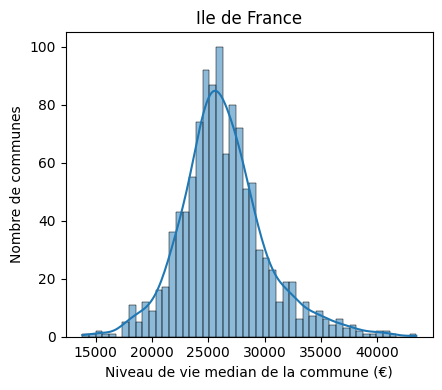

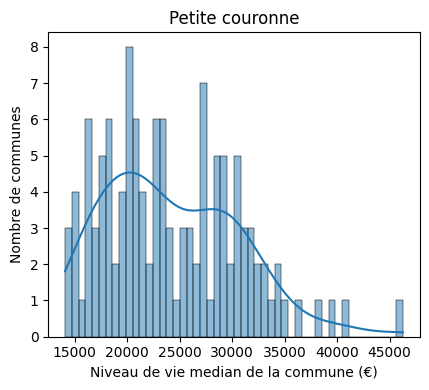

Le niveau de vie median à Paris est de 28270.0 €.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

paris = ['75']
petite_couronne = ['92','93','94']

def zone_dep(dep):
    if dep in paris:
        return 'Paris'
    elif dep in petite_couronne:
        return 'Petite couronne'
    else:
        return 'Ile de France'

path = "cache/cache_pynsee.xlsx"
df = pd.read_excel(path)
df = df[df['UNIT'] == "MEDIANE"]
df = df.rename(columns={"CODEGEO": "Code commune"})
df = df.rename(columns={"OBS_VALUE": "RDB_M"})
df['Code commune'] = df['Code commune'].astype(str)
df['Departement'] = df['Code commune'].str[:2]  
df['zone'] = df['Departement'].apply(zone_dep)

colonnes = ['RDB_M']

def plot_distributions(data, title):
    plt.figure(figsize=(16, 4))
    for i, col in enumerate(colonnes):
        plt.subplot(1, 4, i+1)
        sns.histplot(data[col], bins=50, kde=True)
        plt.title(f"{title}")
        plt.xlabel("Niveau de vie median de la commune (€)")
        plt.ylabel("Nombre de communes")
    plt.tight_layout()
    plt.show()

IdF = df[df['zone'] == 'Ile de France']
Pc = df[df['zone'] == 'Petite couronne']

plot_distributions(IdF, "Ile de France") 
plot_distributions(Pc, "Petite couronne")

rdb_paris_value = df.loc[df['Code commune'] == '75056', 'RDB_M'].values[0]
print(f"Le niveau de vie median à Paris est de {rdb_paris_value} €.")


L’analyse de la distribution du niveau de vie médian révèle une différence intéressante selon l’échelle géographique :

À l’échelle de l’Île-de-France, la distribution apparaît quasi-gaussienne : la majorité des communes se situent autour d’un niveau de vie médian moyen, tandis que les communes très riches ou très modestes sont minoritaires.

En revanche, lorsqu’on se concentre sur la petite couronne, la distribution devient bimodale, avec deux pics distincts. Cela traduit l’hétérogénéité socio-économique de cette zone : certaines communes sont très aisées et résidentielles (par exemple Neuilly-sur-Seine ou Boulogne-Billancourt), tandis que d’autres présentent des niveau de vie plus modestes (notamment certaines parties de Seine-Saint-Denis). 

La coexistence de ces deux types de communes crée deux groupes de niveau de vie distincts, expliquant le caractère bimodal observé. Cette observation est utile pour interpréter les modèles de prédiction : elle montre que la variabilité locale peut être très différente de la tendance régionale globale.

In [7]:
import folium
import branca.colormap as cm
import geopandas as gpd

# Charger les communes
communes = gpd.read_file("cache/cartiflette/communes_idf.geojson")
communes['Code commune'] = communes['INSEE_COM'].astype(str)
communes = communes.merge(df[['Code commune', 'RDB_M']], on='Code commune', how='left')

# Créer la colormap
cmap = cm.LinearColormap(
    colors=['yellow', 'red'],
    vmin=communes['RDB_M'].min(),
    vmax=communes['RDB_M'].max(),
    caption='Revenu médian (€)'
)

# Carte centrée sur IDF avec fond blanc
m = folium.Map(
    location=[48.85, 2.35],
    zoom_start=10,
    tiles=None  # fond blanc
)

# Ajouter les polygones avec tooltip
folium.GeoJson(
    communes,
    style_function=lambda feature: {
        'fillColor': cmap(feature['properties']['RDB_M']) if feature['properties']['RDB_M'] is not None else '#ffffff',
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['NOM', 'RDB_M'],
        aliases=['Commune', 'Niveau de vie médian (€)'],
        localize=True
    )
).add_to(m)

# Ajouter la légende
cmap.add_to(m)

# Sauvegarder
m.save("assets/maps/niveau_vie.html")

[![Interactive map](/assets/maps/niveau_vie.png)](/assets/maps/niveau_vie.html)

L’analyse graphique des cartes révèle un lien clair entre la répartition du niveau de vie médian et les erreurs de notre modèle. Sur la carte de l’Île-de-France, on observe que les communes où le niveau de vie est le plus élevé coïncident souvent avec des zones où le modèle sous-estimait les prix, tandis que les communes aux niveaux de vie plus faibles correspondaient à des surestimations.

Ce contraste visuel montre que le **profil spatial du niveau de vie médian est quasiment l’inverse des erreurs de prédiction** (cf partie suivante). Intégrer cette variable dans le modèle apparaît donc particulièrement pertinent : elle fournit une information socio-économique clé qui complète les caractéristiques des biens et de l’offre de transport, et devrait permettre de corriger les biais observés, rendant les prédictions plus précises et homogènes sur le territoire.

# Visualisation du dataframe final

On enregistre le dataframe et on le visualise :

In [8]:
# Enregistrement des données finales

gdf_dvf_final['Department'] = gdf_dvf_final['Department'].astype(str)
gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].astype(str)
gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].str.zfill(3)
gdf_dvf_final['Code commune'] = (
    gdf_dvf_final['Department'] + gdf_dvf_final['Code commune']
)
gdf_dvf_final.loc[gdf_dvf_final['Commune'] == 'PARIS', 'Code commune'] = '75056'

gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].astype(str)
df['Code commune'] = df['Code commune'].astype(str)

gdf_dvf_final = gdf_dvf_final.merge(
    df[['Code commune', 'RDB_M']],
    on='Code commune',
    how='left'
)

cols_to_drop = [
    'result_score_next', 'result_label', 'result_type', 'result_id', 
    'result_housenumber', 'result_name', 'result_street', 'result_postcode', 
    'result_city', 'result_context', 'result_citycode', 'result_oldcitycode', 
    'result_oldcity', 'result_district', 'result_status'
]

# Supprimer les colonnes
gdf_dvf_final = gdf_dvf_final.drop(columns=cols_to_drop, errors='ignore')

# enregistrer le GeoDataFrame final en GeoJSON
gdf_dvf_final.to_file("cache/results/logements_transport_final.geojson", driver="GeoJSON", encoding="utf-8")


In [9]:
# visualisation de`` statistiques descriptives

from great_tables import GT
import numpy as np
import pandas as pd


gdf_dvf_final_filtred = gdf_dvf_final.drop(columns=['nearest_tramway_stop_id', 'nearest_train_stop_id', 'nearest_bus_stop_id', 'nearest_metro_stop_id'])

groups = ["Localisation"] * 6 + ["Caractéristiques du logement"] * 5 + ["Distances des transports"] * 4 + ["Transports dans un rayon de 1km"] * (len(gdf_dvf_final_filtred.columns) - 16) + ["Niveau de vie local"]

# compute stats for each column
rows = []
for col in gdf_dvf_final_filtred.columns:

    if pd.api.types.is_numeric_dtype(gdf_dvf_final_filtred[col]):
        min_s = f"{gdf_dvf_final_filtred[col].min():,.1f}"
        max_s = f"{gdf_dvf_final_filtred[col].max():,.1f}"
        mean_s = f"{gdf_dvf_final_filtred[col].mean():,.1f}"
        quartile_25 = f"{gdf_dvf_final_filtred[col].quantile(0.25):,.1f}"
        median = f"{gdf_dvf_final_filtred[col].median():,.1f}"
        quartile_75 = f"{gdf_dvf_final_filtred[col].quantile(0.75):,.1f}"
    else:
        try:
            min_s = str(gdf_dvf_final_filtred[col].min())
            max_s = str(gdf_dvf_final_filtred[col].max())
            # crop long strings for display
            if len(min_s) > 7:
                min_s = min_s[:4] + "..."
            if len(max_s) > 7:
                max_s = max_s[:4] + "..."
        except Exception:
            min_s = max_s = "-"
        mean_s = "-"
        cv_s = "-"
        quartile_25 = "-"
        median = "-"
        quartile_75 = "-"

    rows.append({"index": col, "Moyenne": mean_s, "Min": min_s, "25%": quartile_25, "50%": median, "75%": quartile_75, "Max": max_s,})

df_stats = pd.DataFrame(rows).assign(group=groups)

(
    GT(df_stats)
    .tab_stub(rowname_col="index", groupname_col="group")
    .tab_header("Statistiques descriptives des colonnes du jeu de données")
)

GT(_tbl_data=                             index   Moyenne       Min       25%       50%  \
0                          adresse         -   1 AL...         -         -   
1                      Code_postal         -     75001         -         -   
2              dist_centre_paris_m  26,702.0     137.3   8,720.3  19,904.6   
3                       Department         -        75         -         -   
4                       Type local         -   Appa...         -         -   
5                          Commune         -   ABLE...         -         -   
6              Surface reelle bati      72.8       9.0      40.0      65.0   
7                  Surface terrain     199.6       0.0       0.0       0.0   
8        Nombre pieces principales       3.3       1.0       2.0       3.0   
9                     Code commune         -     75012         -         -   
10  Valeur foncière au mètre carré   5,539.3   1,000.0   3,104.7   4,488.8   
11                        geometry         -         -         -         -   
12              nearest_bus_dist_m     251.9       0.3     145.5     221.0   
13            nearest_metro_dist_m  14,761.2       8.2     633.1   6,343.9   
14          nearest_tramway_dist_m   9,542.9      10.6   1,671.6   3,995.8   
15            nearest_train_dist_m   2,152.6      10.6     935.8   1,543.6   
16           nb_routes_tramway_1km       0.1       0.0       0.0       0.0   
17             nb_routes_metro_1km       0.7       0.0       0.0       0.0   
18             nb_routes_train_1km       0.4       0.0       0.0       0.0   
19               nb_routes_bus_1km       9.3       0.0       5.0       8.0   
20         nb_stations_tramway_1km       0.2       0.0       0.0       0.0   
21           nb_stations_metro_1km       1.1       0.0       0.0       0.0   
22           nb_stations_train_1km       0.3       0.0       0.0       0.0   
23             nb_stations_bus_1km       9.5       0.0       6.0       9.0   
24  passage_journalier_tramway_1km     103.1       0.0       0.0       0.0   
25    passage_journalier_metro_1km   1,069.5       0.0       0.0       0.0   
26    passage_journalier_train_1km     101.0       0.0       0.0       0.0   
27      passage_journalier_bus_1km   2,979.1       0.0     858.0   2,282.0   
28                           RDB_M  25,593.4  13,810.0  22,060.0  26,240.0   

         75%        Max                            group  
0          -    990 ...                     Localisation  
1          -      95880                     Localisation  
2   37,967.6  138,652.3                     Localisation  
3          -         95                     Localisation  
4          -     Maison                     Localisation  
5          -     YERRES                     Localisation  
6       91.0      300.0     Caractéristiques du logement  
7      262.0    9,940.0     Caractéristiques du logement  
8        4.0       20.0     Caractéristiques du logement  
9          -      95690     Caractéristiques du logement  
10   7,544.5   20,000.0     Caractéristiques du logement  
11         -          -         Distances des transports  
12     313.7    4,261.1         Distances des transports  
13  22,282.7  119,312.3         Distances des transports  
14  11,765.8   92,561.1         Distances des transports  
15   2,454.0   35,427.2  Transports dans un rayon de 1km  
16       0.0        3.0  Transports dans un rayon de 1km  
17       1.0        8.0  Transports dans un rayon de 1km  
18       1.0        9.0  Transports dans un rayon de 1km  
19      12.0       48.0  Transports dans un rayon de 1km  
20       0.0        6.0  Transports dans un rayon de 1km  
21       1.0       11.0  Transports dans un rayon de 1km  
22       1.0        3.0  Transports dans un rayon de 1km  
23      13.0       27.0  Transports dans un rayon de 1km  
24       0.0    3,329.0  Transports dans un rayon de 1km  
25     920.0   14,720.0  Transports dans un rayon de 1km  
26      87.0    2,506.0  Transports dans un rayon de 

# Économétrie 

## Préambule

Dans un second temps, l’objectif serait d’adopter une approche économétrique afin de quantifier l’impact des infrastructures de transport sur les prix immobiliers. Une telle analyse soulève toutefois des difficultés méthodologiques majeures. En particulier, la relation entre accessibilité aux transports et prix du logement est sujette à des problèmes de **causalité inverse** : les infrastructures de transport ne sont pas implantées aléatoirement, mais tendent à être développées dans des zones déjà attractives ou en anticipation d’une hausse de la demande immobilière.
Par ailleurs, un **biais d’omission de variables** est susceptible d’affecter les estimations. Des facteurs non observés, tels que les politiques locales d’aménagement, la qualité des services publics ou les dynamiques économiques locales, peuvent simultanément influencer la localisation des transports et le niveau des prix immobiliers. Ces différents mécanismes conduisent à une **endogénéité des variables de transport**, rendant les estimations issues de modèles standards biaisées et **difficilement interprétables sur le plan causal**.
Pour identifier un effet causal crédible, il serait nécessaire de recourir à des **méthodes quasi-expérimentales**. Parmi celles-ci, l’utilisation de variables instrumentales pourrait être envisagée, par exemple en exploitant la présence d’anciennes lignes ferroviaires comme instrument de l’accessibilité actuelle aux transports. Une autre approche consisterait à mettre en œuvre une méthode de différences-en-différences, en comparant l’évolution des prix immobiliers dans les zones affectées par l’ouverture de nouvelles lignes de transport à celle de zones similaires non concernées.

Faute de données suffisantes et en raison de contraintes de temps, nous avons mené une analyse qui ne peut prétendre à l’identification d’un effet causal. Elle demeure néanmoins pertinente en ce qu’elle complète l’analyse précédente en apportant des éléments descriptifs et exploratoires sur la relation entre accessibilité aux transports et prix immobiliers. Cette approche permet de mettre en évidence des corrélations structurantes et d’orienter de futures recherches, qui pourraient s’appuyer sur des données plus riches et des méthodes économétriques adaptées afin d’identifier rigoureusement les mécanismes causaux sous-jacents. 

## Méthodologie 

### 1. Analyse exploratoire des corrélations

Dans un premier temps, une analyse exploratoire des données est réalisée à l’aide de matrices de corrélation portant sur l’ensemble des variables numériques. Cette étape permet d’identifier la présence de fortes corrélations, en particulier entre les variables décrivant l’accessibilité et l’offre de transport (distances aux infrastructures, nombre de lignes et de stations, volumes de passages journaliers). Ces corrélations élevées indiquent un risque important de multicolinéarité si ces variables sont introduites simultanément dans un modèle de régression linéaire classique.

### 2. Réduction de dimension par Analyse en Composantes Principales (ACP)

Afin de traiter la multicolinéarité et de synthétiser l’information contenue dans les variables de transport, une Analyse en Composantes Principales (ACP) est appliquée exclusivement à ces variables.  
Avant l’ACP, l’ensemble des variables de transport est standardisé afin de garantir une contribution équivalente de chaque variable à la construction des composantes.

Les cinq premières composantes principales sont conservées. Ce choix repose sur :
- le critère de Kaiser (valeurs propres supérieures à 1),
- l’analyse du scree plot,
- et la part de variance expliquée cumulée, jugée suffisante pour résumer l’information pertinente liée aux transports.


### 3. Sélection des variables par Lasso

Dans un second temps, une procédure de sélection de variables est menée à l’aide d’une régression Lasso avec validation croisée (LassoCV). Cette méthode est particulièrement adaptée dans un contexte où le nombre de variables explicatives est élevé et potentiellement corrélé, car elle pénalise les coefficients et peut en annuler certains.

Les variables explicatives sont standardisées, condition indispensable au bon fonctionnement du Lasso. La variable dépendante est la valeur foncière au mètre carré, exprimée en logarithme afin de :
- réduire l’asymétrie de la distribution des prix,
- limiter l’influence des valeurs extrêmes,
- permettre une interprétation en termes de semi-élasticité.

Le Lasso permet ainsi d’identifier un sous-ensemble de variables pertinentes, incluant à la fois des caractéristiques intrinsèques des biens, des variables socio-économiques et les composantes principales liées aux transports.

### 4. Estimation du modèle OLS log-niveau

À partir des variables sélectionnées, un modèle de régression linéaire est estimé par la méthode des moindres carrés ordinaires (OLS). Le modèle retenu est de type **log-niveau**, où le logarithme du prix au mètre carré est expliqué par des variables exprimées en niveau.

### 5. Limites de l’approche

Bien que cette méthodologie permette de structurer l’information, de limiter la multicolinéarité et d’identifier des relations statistiques robustes, elle ne permet pas d’identifier des effets causaux. Les variables liées aux transports restent potentiellement endogènes en raison de phénomènes de causalité inverse et de variables omises. En l’absence de données temporelles détaillées ou de chocs exogènes exploitables, l’analyse doit être interprétée comme descriptive et corrélationnelle.


In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# Load a sample geospatial dataset
gdf = gpd.read_file("cache/results/logements_transport_final.geojson")

# Display the first few rows of the GeoDataFrame
# ensure every column is shown
pd.set_option('display.max_columns', None)
print(gdf.keys())

gdf = gdf.drop(columns=["adresse", "Commune", "Code commune",
                        "nearest_bus_stop_id", "nearest_metro_stop_id",
                        "nearest_train_stop_id", "nearest_tramway_stop_id"])
save_gdf = gdf.copy()

Index(['adresse', 'Code_postal', 'dist_centre_paris_m', 'Department',
       'Type local', 'Commune', 'Surface reelle bati', 'Surface terrain',
       'Nombre pieces principales', 'Code commune',
       'Valeur foncière au mètre carré', 'nearest_bus_stop_id',
       'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m',
       'nearest_tramway_stop_id', 'nearest_tramway_dist_m',
       'nearest_train_stop_id', 'nearest_train_dist_m',
       'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km',
       'nb_routes_bus_1km', 'nb_stations_tramway_1km', 'nb_stations_metro_1km',
       'nb_stations_train_1km', 'nb_stations_bus_1km',
       'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
       'passage_journalier_train_1km', 'passage_journalier_bus_1km', 'RDB_M',
       'geometry'],
      dtype='object')


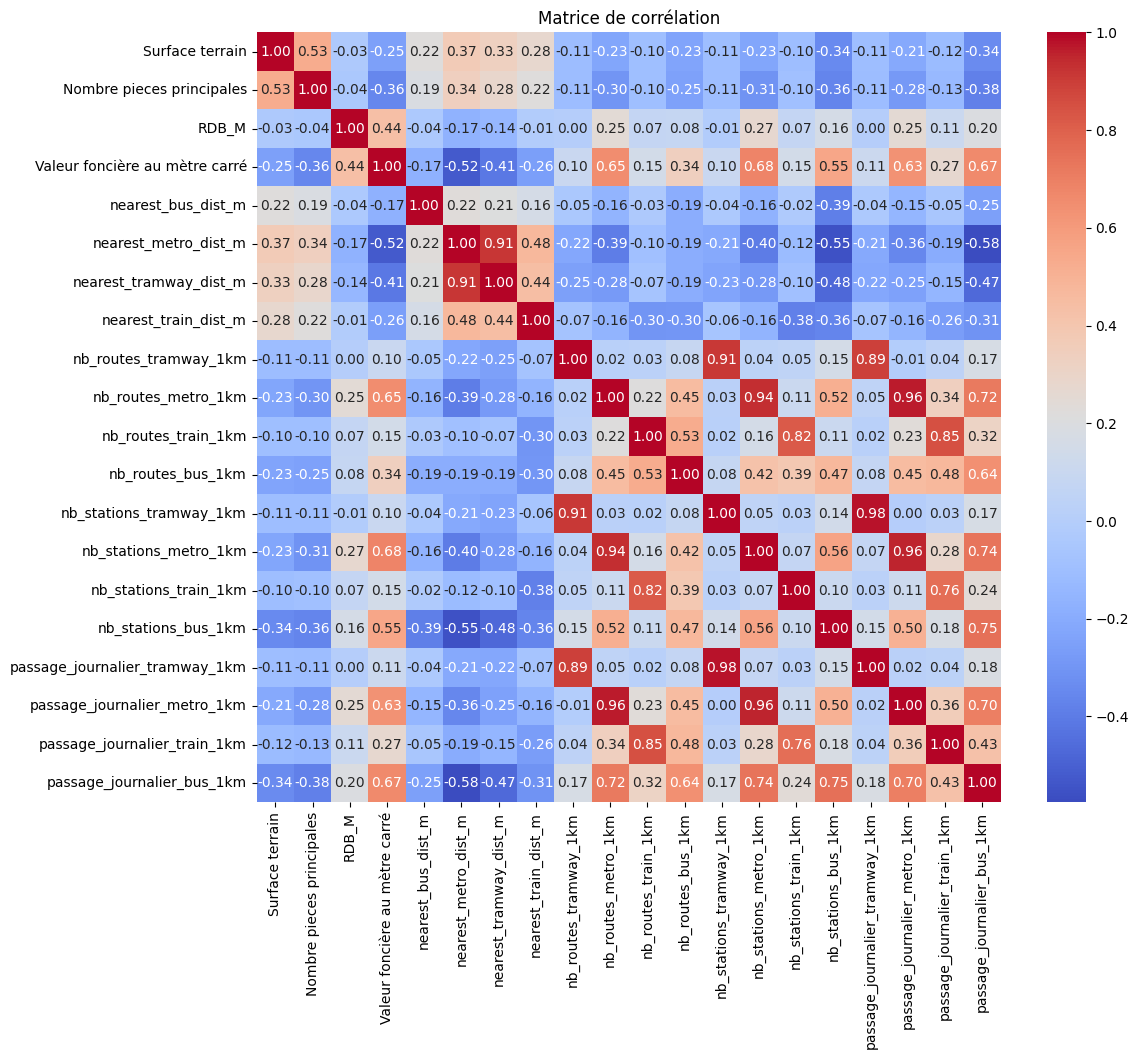

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 

numerical_vars = [
    'Surface terrain', 'Nombre pieces principales','RDB_M',
    'Valeur foncière au mètre carré', 
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

gdf_num = gdf[numerical_vars]

corr_matrix = gdf_num.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

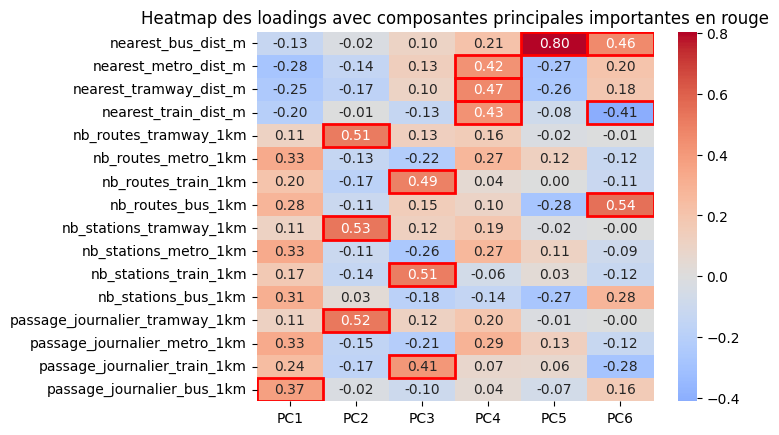

In [13]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Sélection des variables de transport ---
transport_vars = [
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

X = gdf[transport_vars]

# --- Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ACP ---
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

# --- DataFrame des loadings ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(6)], 
                        index=transport_vars)

# --- Heatmap des loadings ---

sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f")

# Ajouter un rectangle rouge autour des valeurs "importantes"
threshold = 0.35
for i, col in enumerate(loadings.columns):
    for j, val in enumerate(loadings[col]):
        if abs(val) > threshold:
            plt.gca().add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor='red', lw=2))

plt.title("Heatmap des loadings avec composantes principales importantes en rouge")
plt.show()

,Composante,Variance expliquée,Variance cumulée
0,PC1,0.358,0.358
1,PC2,0.183,0.540
2,PC3,0.149,0.689
3,PC4,0.102,0.792
4,PC5,0.062,0.853
5,PC6,0.040,0.894


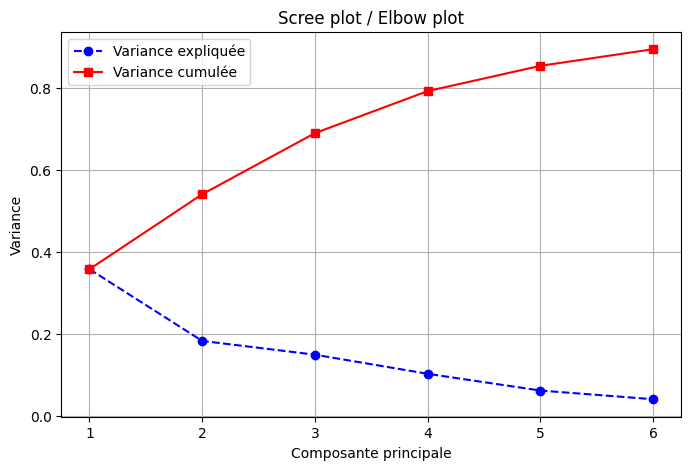

In [14]:
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import pandas as pd

# Variance expliquée et cumulée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Création du DataFrame
df_variance = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Variance expliquée': explained_variance.round(3),
    'Variance cumulée': cumulative_variance.round(3)
})

# Affichage avec titre
display(HTML("<h3>Variance expliquée et cumulée par composante</h3>"))
display(df_variance)

# Scree plot
composantes = range(1, len(explained_variance)+1)

plt.figure(figsize=(8,5))
plt.plot(composantes, explained_variance, marker='o', linestyle='--', color='b', label='Variance expliquée')
plt.plot(composantes, [sum(explained_variance[:i]) for i in composantes], marker='s', linestyle='-', color='r', label='Variance cumulée')
plt.xlabel('Composante principale')
plt.ylabel('Variance')
plt.title('Scree plot / Elbow plot')
plt.xticks(composantes)
plt.grid(True)
plt.legend()
plt.show()


In [15]:

valeurs_propres = pca.explained_variance_

# Création du DataFrame
df_valeurs_propres = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(valeurs_propres))],
    'Valeur propre': valeurs_propres
})

# Formater les valeurs propres avec 2 décimales pour plus de lisibilité
df_valeurs_propres['Valeur propre'] = df_valeurs_propres['Valeur propre'].apply(lambda x: round(x, 2))

# Affichage avec un titre et bordures pour plus de lisibilité (si tu utilises Jupyter Notebook)
from IPython.display import display, HTML
print("=== Valeurs propres des composantes principales (critère de Kaiser) ===")
display(HTML(df_valeurs_propres.to_html(index=False)))



=== Valeurs propres des composantes principales (critère de Kaiser) ===


Composante,Valeur propre
PC1,5.72
PC2,2.92
PC3,2.39
PC4,1.64
PC5,0.99
PC6,0.65


## Résultats des composantes principales (ACP)

**Part de variance expliquée**

Les résultats montrent que les six premières composantes principales expliquent une part substantielle de la variance totale des variables de transport :
PC1 explique à elle seule 35,8 % de la variance totale. Elle capte donc la dimension dominante de l’accessibilité aux transports et résume une large part de l’information initiale.
PC2 explique 18,3 % supplémentaires, portant la variance cumulée à 54,0 %. Elle correspond à une seconde dimension structurante, distincte de la première.
PC3 contribue à hauteur de 14,9 %, ce qui permet d’atteindre 68,9 % de variance cumulée.
PC4 ajoute 10,2 %, portant la variance cumulée à 79,2 %.
PC5 explique 6,2 % supplémentaires, pour une variance cumulée de 85,3 %.
Les composantes suivantes (PC6 et au-delà) n’apportent qu’un gain marginal d’information. PC6 n’explique que 4,0 % de la variance, ce qui suggère un contenu informationnel limité.

**Interprétation des valeurs propres (critère de Kaiser)**

L’analyse des valeurs propres confirme ces résultats :
PC1 (5,72), PC2 (2,92), PC3 (2,39) et PC4 (1,64) ont des valeurs propres nettement supérieures à 1, ce qui indique qu’elles expliquent davantage de variance qu’une variable initiale moyenne. Elles sont donc pleinement justifiées selon le critère de Kaiser.
PC5 (0,99) se situe à la frontière du seuil de 1. Bien qu’elle ne respecte pas strictement le critère de Kaiser, elle reste proche du seuil et apporte une information complémentaire pertinente, notamment pour capter des dimensions plus spécifiques de l’accessibilité.
PC6 (0,65) a une valeur propre nettement inférieure à 1, ce qui indique qu’elle contient moins d’information qu’une variable initiale standardisée et ne justifie pas sa conservation.

**Justification du nombre de composantes retenues**

Le choix de conserver les cinq premières composantes principales repose sur un compromis entre :
une forte capacité explicative (plus de 85 % de la variance totale),
le respect global du critère de Kaiser,
et la lisibilité économique des composantes.
Cette sélection permet de résumer efficacement l’information contenue dans les variables de transport tout en évitant une perte excessive d’information. Elle garantit également une utilisation parcimonieuse des composantes dans le modèle de régression, limitant les risques de sur-ajustement.

## Interprétation des composantes principales (ACP)

L’Analyse en Composantes Principales (ACP) permet de résumer l’information contenue dans un grand nombre de variables de transport fortement corrélées en un nombre réduit de facteurs synthétiques, appelés composantes principales. Chaque composante est une combinaison linéaire des variables initiales, pondérées par des coefficients appelés loadings. Ces loadings indiquent la contribution relative de chaque variable à la composante considérée.

**PC1 – Intensité globale de l’offre de transport**
La première composante principale (PC1) est caractérisée par des coefficients positifs relativement élevés pour :
le nombre de lignes et de stations (bus, métro),
les volumes de passages journaliers, en particulier pour le bus.
Cette composante capture donc une intensité globale de l’offre de transport et de la fréquentation dans un rayon proche. Des valeurs élevées de PC1 correspondent à des zones bien desservies, avec une forte densité de réseaux et une activité de transport importante.

**PC2 – Présence du tramway**
La deuxième composante (PC2) est dominée par :
le nombre de lignes et de stations de tramway,
les passages journaliers du tramway.
Elle reflète une structuration locale autour du réseau de tramway, souvent associée à des zones urbaines denses ou récemment aménagées. Cette composante distingue donc les territoires où le tramway joue un rôle central dans l’accessibilité.

**PC3 – Accessibilité ferroviaire (train)**
La troisième composante (PC3) est principalement portée par :
le nombre de lignes et de stations de train,
les passages journaliers ferroviaires.
PC3 peut être interprétée comme une mesure de l’accessibilité aux réseaux ferroviaires lourds, souvent liée à des connexions interurbaines ou régionales.

**PC4 – Proximité aux infrastructures de transport**
La quatrième composante (PC4) est dominée par des coefficients positifs sur les distances aux stations (métro, tramway, train). Elle mesure essentiellement la proximité physique aux infrastructures de transport : des valeurs élevées correspondent à des biens situés plus loin des stations, tandis que des valeurs faibles traduisent une meilleure accessibilité spatiale.

**PC5 – Éloignement spécifique du réseau de bus**
Enfin, la cinquième composante (PC5) est très fortement corrélée à la distance au bus le plus proche. Elle capte donc une dimension spécifique d’isolement vis-à-vis du réseau de bus, indépendante des autres modes de transport.

In [16]:

# On ne garde que les 5 premières
for i in range(5):
    gdf[f'PC{i+1}_transport'] = X_pca[:, i]

# Liste des colonnes PCA existantes ou variables de transport à supprimer
transport_vars = [
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

# Supprimer les colonnes de transport et les anciennes colonnes PCA si elles existent
cols_to_drop = transport_vars + [f'PC{i}_transport' for i in range(6, gdf.shape[1])]
gdf = gdf.drop(columns=[c for c in cols_to_drop if c in gdf.columns])

# Vérifier le résultat
gdf.head()

,Code_postal,dist_centre_paris_m,Department,Type local,Surface reelle bati,Surface terrain,Nombre pieces principales,Valeur foncière au mètre carré,RDB_M,geometry,PC1_transport,PC2_transport,PC3_transport,PC4_transport,PC5_transport
0,93250,18495.327994,93,Appartement,37.0,0.0,2.0,4135.135135,22880.0,POINT (2.50639 48.89254),0.997985,4.280303,2.337315,0.028139,-0.151055
1,77370,91147.159895,77,Maison,81.0,232.0,4.0,2888.888889,18930.0,POINT (3.02135 48.55532),-2.825424,-1.133448,0.628336,2.070559,-1.743891
2,78260,35301.849789,78,Maison,88.0,408.0,4.0,3784.090909,21970.0,POINT (2.06194 48.9531),-1.078894,-0.091095,-0.596419,-0.461512,-0.388915
3,92140,11748.500396,92,Maison,95.0,0.0,4.0,7476.315789,27580.0,POINT (2.27316 48.8121),0.472067,-0.538313,1.333239,-1.534365,0.101122
4,93290,29249.801463,93,Appartement,63.0,0.0,4.0,2523.809524,20710.0,POINT (2.57231 48.95058),-1.121200,-0.058976,-0.355989,-0.976304,-0.330384


Statistiques descriptives des PC de transport :
                 count          mean       std       min       25%       50%  \
PC1_transport  72596.0 -3.601848e-17  2.391795 -8.976542 -1.551666 -0.423699   
PC2_transport  72596.0  1.526870e-17  1.709483 -6.220330 -0.750947 -0.248019   
PC3_transport  72596.0  6.264083e-18  1.544374 -4.775593 -0.692752 -0.267124   
PC4_transport  72596.0  5.060204e-17  1.280406 -2.021328 -0.936813 -0.303057   
PC5_transport  72596.0  1.291967e-17  0.993094 -4.015933 -0.529538 -0.049511   

                    75%        max      range  
PC1_transport  1.387500  13.515312  22.491854  
PC2_transport  0.041806  13.386020  19.606349  
PC3_transport  0.752120   9.330025  14.105618  
PC4_transport  0.619361  11.826213  13.847540  
PC5_transport  0.477998  17.307410  21.323343  

Statistiques descriptives des PC normalisées :
                 count          mean       std       min       25%       50%  \
PC1_transport  72596.0 -7.830103e-18  1.000007 -3.75308

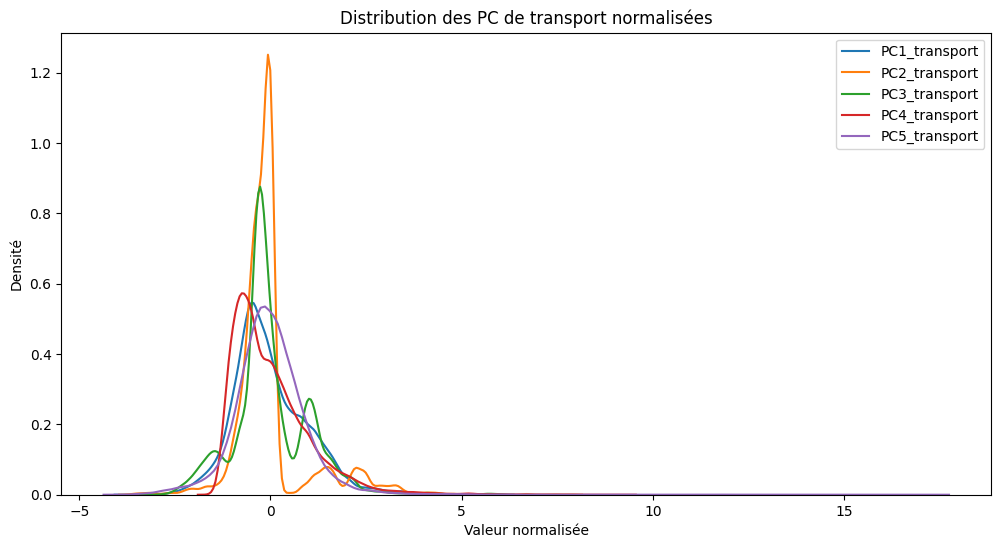

Moyenne des PC normalisées :
PC1_transport   -0.0
PC2_transport    0.0
PC3_transport    0.0
PC4_transport    0.0
PC5_transport    0.0
dtype: float64

Écart-type des PC normalisées :
PC1_transport    1.0
PC2_transport    1.0
PC3_transport    1.0
PC4_transport    1.0
PC5_transport    1.0
dtype: float64


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sélection des 5 PC de transport ---
pc_vars = [f'PC{i+1}_transport' for i in range(5)]
df_pc = gdf[pc_vars].dropna()  # retirer éventuels NaN

# --- Statistiques descriptives avant normalisation ---
desc_stats = df_pc.describe().T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
print("Statistiques descriptives des PC de transport :")
print(desc_stats)

# --- Normalisation (centré réduit) ---
scaler = StandardScaler()
df_pc_scaled = pd.DataFrame(scaler.fit_transform(df_pc), columns=pc_vars, index=df_pc.index)

# --- Remplacer les PC originales dans le DataFrame par les versions normalisées ---
gdf.loc[df_pc_scaled.index, pc_vars] = df_pc_scaled

# --- Statistiques descriptives après normalisation ---
desc_stats_scaled = df_pc_scaled.describe().T
desc_stats_scaled['range'] = desc_stats_scaled['max'] - desc_stats_scaled['min']
print("\nStatistiques descriptives des PC normalisées :")
print(desc_stats_scaled)

# --- Visualisation des distributions normalisées ---
plt.figure(figsize=(12,6))
for pc in pc_vars:
    sns.kdeplot(gdf[pc], label=pc)
plt.title("Distribution des PC de transport normalisées")
plt.xlabel("Valeur normalisée")
plt.ylabel("Densité")
plt.legend()
plt.show()


# --- Vérification des statistiques globales après normalisation ---
print("Moyenne des PC normalisées :")
print(gdf[pc_vars].mean().round(3))
print("\nÉcart-type des PC normalisées :")
print(gdf[pc_vars].std().round(3))


Pour rendre les composantes principales (PCA) comparables et interprétables dans notre modèle de prix immobilier, nous avons normalisé les cinq premières PCA (centrage à 0 et réduction à un écart-type). Cette normalisation permet de mettre toutes les composantes sur la même échelle, évitant qu’une PCA domine simplement à cause des unités de ses variables constitutives (distance, nombre de stations, passage journalier, etc.). Elle facilite également l’interprétation des coefficients dans les régressions : chaque coefficient reflète l’effet d’un écart-type de la composante sur le prix au m², ce qui rend les effets relatifs des différentes PCA directement comparables.

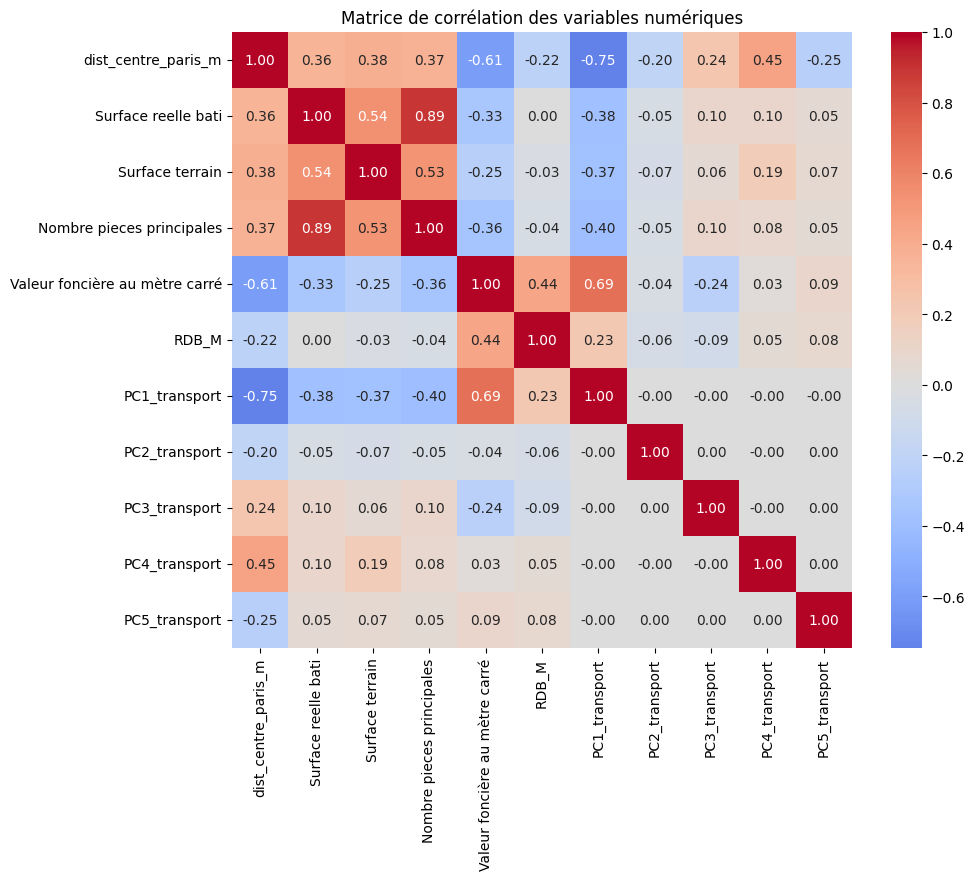

In [18]:
# --- Matrice de corrélation des variables numériques ---
gdf_numeric = gdf.select_dtypes(include='number')
corr_matrix = gdf_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

### Exploration des corrélations

**LES CORRÉLATIONS FORTES**

 **Relations positives fortes**
- **Surface bâtie ↔ Nombre de pièces**  +0.89  
  → plus grande surface = plus de pièces
  → Attention à la multicolinéarité
- **Surface bâtie ↔ Surface terrain**  +0.54  
  →  grandes constructions sur grands terrains
- **Nombre pièces ↔ Surface terrain**  +0.53  
  → plus de pièces nécessite plus d'espace

**Relations négatives fortes**
- **Distance centre Paris ↔ PC1_transport**  -0.75  
  → plus on est proche du centre, plus le transport est dense
- **Distance centre Paris ↔ Prix au m²**  -0.61  
  → la centralité fait monter les prix
- **PC1_transport ↔ Prix au m²**  +0.69  
  → les zones bien desservies sont plus chères

**LES CORRÉLATIONS MODÉRÉES**

**Positives modérées**
- **Distance centre Paris ↔ PC4_transport**  +0.45  
  → en s'éloignant du centre, on s'éloigne des stations
- **Surface bâtie ↔ Distance centre Paris**  +0.36  
  → les biens plus grands sont plus éloignés
- **Nombre pièces ↔ Distance centre Paris**  +0.37  
  → les biens plus grands sont plus éloignés
- **Niveau de vie ↔ Prix au m²** → +0.44  
  les zones chères sont celles ou le niveau de vie moyen est le plus élevés

 **Négatives modérées**
- **Surface bâtie ↔ Prix au m²**  -0.33  
  → décote des grandes surfaces
- **Nombre pièces ↔ Prix au m²**  -0.36  
  → décote des grandes surfaces


In [19]:
print("Nombre de NaN par colonne :")
print(gdf_numeric.isna().sum())

Nombre de NaN par colonne :
dist_centre_paris_m                 0
Surface reelle bati               190
Surface terrain                    38
Nombre pieces principales         190
Valeur foncière au mètre carré      0
RDB_M                              93
PC1_transport                       0
PC2_transport                       0
PC3_transport                       0
PC4_transport                       0
PC5_transport                       0
dtype: int64


### Interprétation du modèle Lasso pour la sélection de variables

Le modèle Lasso applique une régularisation L1 qui a pour effet de **forcer certains coefficients à zéro**, ce qui permet de **sélectionner automatiquement les variables les plus importantes** à inclure dans une régression linéaire classique (OLS). Dans notre modèle, les coefficients les plus élevés en valeur absolue sont `log_dist_centre_paris_m` (-0.31) et `log_RDB_M` (0.16), indiquant que la distance au centre de Paris et la surface RDB_M sont les variables les plus influentes sur le prix au m². D’autres variables comme `Surface reelle bati`, `Nombre pieces principales` ou certaines composantes `PC_transport` sont conservées avec un coefficient faible, montrant qu’elles ont un effet secondaire mais non négligeable. Les variables mises à zéro par Lasso (`PC2_transport`, `PC3_transport`, `PC5_transport`, `Surface terrain`) sont jugées peu informatives et peuvent être exclues de l’OLS.  

En jouant sur la valeur de **alpha** (la force de la pénalité), on peut contrôler combien de variables sont supprimées : un alpha trop élevé supprime trop de variables, tandis qu’un alpha trop faible conserve presque toutes les variables. Ici, avec l’alpha choisi par cross-validation dans `[0.01, 0.05, 0.1]`, Lasso fournit un compromis raisonnable entre **simplicité du modèle et inclusion des variables les plus pertinentes** pour l’OLS.

In [20]:
df_model = gdf.copy()

# Transformation log (attention aux valeurs 0 ou négatives : ajouter un petit +1 si besoin)
df_model['log_dist_centre_paris_m'] = np.log(df_model['dist_centre_paris_m'].replace(0, np.nan)).fillna(method='bfill')

# Si RDB_M contient des 0, ajouter 1 sinon log directement
df_model['log_RDB_M'] = np.log(df_model['RDB_M'].replace(0, np.nan)).fillna(method='bfill')

# Log prix cible
df_model['log_valeur_fonciere_m2'] = np.log(df_model['Valeur foncière au mètre carré'])

# Variables en niveau non transformées
variables_niveau = ['Surface reelle bati', 'Surface terrain', 'Nombre pieces principales', 
                   'PC1_transport', 'PC2_transport', 'PC3_transport', 'PC4_transport', 'PC5_transport']

# Variables finales à utiliser dans Lasso (log ou niveau)
X_vars = ['log_dist_centre_paris_m', 'log_RDB_M'] + variables_niveau
y_var = 'log_valeur_fonciere_m2'

# Nettoyer NaN
df_model_clean = df_model.dropna(subset=X_vars + [y_var])

# Préparer X et y
X = df_model_clean[X_vars]
y = df_model_clean[y_var]

# Standardiser X avant Lasso
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lasso
from sklearn.linear_model import LassoCV
lasso = LassoCV(alphas = [0.01, 0.05, 0.1] , cv=5, random_state=42)
lasso.fit(X_scaled, y)

# Coefficients
import pandas as pd
coef = pd.Series(lasso.coef_, index=X.columns)
print("Coefficients Lasso :")
print(coef.sort_values(ascending=False))

# Variables sélectionnées (coef != 0)
selected_vars = coef[coef != 0].index.tolist()

# Variables “supprimées” par Lasso (coef = 0)
lasso_removed_vars = coef[coef == 0].index.tolist()

print("\nVariables conservées par Lasso :")
print(selected_vars)

print("\nVariables supprimées par Lasso (coef = 0) :")
print(lasso_removed_vars)


/tmp/ipykernel_108507/1380704116.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model['log_dist_centre_paris_m'] = np.log(df_model['dist_centre_paris_m'].replace(0, np.nan)).fillna(method='bfill')
/tmp/ipykernel_108507/1380704116.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model['log_RDB_M'] = np.log(df_model['RDB_M'].replace(0, np.nan)).fillna(method='bfill')


Coefficients Lasso :
log_RDB_M                    0.158618
PC1_transport                0.043763
PC5_transport                0.000000
Surface terrain              0.000000
PC3_transport               -0.000000
PC2_transport                0.000000
PC4_transport               -0.018319
Nombre pieces principales   -0.035292
Surface reelle bati         -0.058031
log_dist_centre_paris_m     -0.312583
dtype: float64

Variables conservées par Lasso :
['log_dist_centre_paris_m', 'log_RDB_M', 'Surface reelle bati', 'Nombre pieces principales', 'PC1_transport', 'PC4_transport']

Variables supprimées par Lasso (coef = 0) :
['Surface terrain', 'PC2_transport', 'PC3_transport', 'PC5_transport']


In [24]:
import statsmodels.api as sm

# Préparer X pour l'OLS avec seulement les variables sélectionnées par Lasso
X_selected = df_model_clean[selected_vars]

# Ajouter une constante pour l'intercept
X_selected = sm.add_constant(X_selected)

# Définir la variable cible
y = df_model_clean[y_var]  # log_valeur_fonciere_m2

# Estimation OLS
ols_model = sm.OLS(y, X_selected).fit()

# Résumé du modèle
print(ols_model.summary())


                              OLS Regression Results                              
Dep. Variable:     log_valeur_fonciere_m2   R-squared:                       0.663
Model:                                OLS   Adj. R-squared:                  0.663
Method:                     Least Squares   F-statistic:                 2.375e+04
Date:                    Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                            23:48:17   Log-Likelihood:                -24297.
No. Observations:                   72368   AIC:                         4.861e+04
Df Residuals:                       72361   BIC:                         4.867e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

### Interprétation du modèle OLS

Le modèle OLS estime les effets des variables sélectionnées par Lasso sur le log du prix au m² (`log_valeur_fonciere_m2`).  

- **Qualité du modèle :**  
  - R² = 0.663 → environ 66% de la variance du prix au m² est expliquée par les variables incluses.  
  - F-statistic très élevée (2.375e+04, p < 0.001) → le modèle est globalement significatif.  

- **Constante (`const`) :** 3.3065 → valeur moyenne de `log_valeur_fonciere_m2` lorsque toutes les variables explicatives sont à zéro (interprétation théorique).  

- **Variables explicatives :**  
  - `log_dist_centre_paris_m` = -0.3172 : plus la distance au centre augmente, plus le prix au m² diminue. Effet fort et très significatif (p < 0.001).  
  - `log_RDB_M` = 0.8309 : plus la surface RDB_M est grande, plus le prix au m² augmente. Effet positif très fort.  
  - `Surface reelle bati` = -0.0014 : coefficient négatif mais très faible, indiquant un effet quasi-nul sur le prix au m².  
  - `Nombre pieces principales` = -0.0198 : effet négatif modéré sur le prix au m².  
  - `PC1_transport` = 0.0502 : effet positif, plus l’accessibilité transport (PC1) est élevée, plus le prix au m² augmente.  
  - `PC4_transport` = -0.0285 : effet négatif modéré, plus les transport les plus proche sont loins, plus le prix au m² est faible.  

- **Significativité :**  
  - Toutes les variables ont p < 0.001 → coefficients statistiquement très significatifs.  

- **Remarques :**  
  La variable `Surface reelle bati` a un impact quasi nul sur le prix et est fortement corrélée avec `Nombre pieces principales`. Pour simplifier le modèle et éviter la multicolinéarité, il est pertinent de recalculer l’OLS en retirant complètement `Surface reelle bati`.



In [25]:
import statsmodels.api as sm

# Préparer X pour l'OLS avec seulement les variables sélectionnées par Lasso
X_selected = df_model_clean[selected_vars].copy()
X_selected = X_selected.drop(columns=[ 'Surface reelle bati'])

# Ajouter une constante pour l'intercept
X_selected = sm.add_constant(X_selected)

# Définir la variable cible
y = df_model_clean[y_var]  # log_valeur_fonciere_m2

# Estimation OLS
ols_model = sm.OLS(y, X_selected).fit()

# Résumé du modèle
print(ols_model.summary())


                              OLS Regression Results                              
Dep. Variable:     log_valeur_fonciere_m2   R-squared:                       0.661
Model:                                OLS   Adj. R-squared:                  0.661
Method:                     Least Squares   F-statistic:                 2.820e+04
Date:                    Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                            23:48:17   Log-Likelihood:                -24554.
No. Observations:                   72368   AIC:                         4.912e+04
Df Residuals:                       72362   BIC:                         4.917e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

### Interprétation du modèle OLS recalculé

Après avoir retiré la variable `Surface reelle bati`, le modèle OLS reste globalement similaire au précédent en termes de qualité :  
- R² = 0.661 (légèrement inférieur à 0.663) → le pouvoir explicatif du modèle reste élevé.  
- F-statistic reste très significative.  

Les coefficients montrent peu de changement pour les variables principales :  
- `log_dist_centre_paris_m` et `log_RDB_M` conservent leurs effets forts et significatifs.  
- `Nombre pieces principales` voit son coefficient devenir légèrement plus négatif (-0.0491 contre -0.0198), reflétant désormais mieux son effet isolé sans redondance avec `Surface reelle bati`.  
- Les effets de `PC1_transport` et `PC4_transport` restent comparables.  

# Conclusion 

Ce travail a permis de mettre en lumière, de manière rigoureuse, les **corrélations entre les prix immobiliers et l’offre de transport** en Ile de France, en intégrant à la fois les caractéristiques des biens et les composantes liées aux infrastructures de transport. Bien que l’analyse reste **descriptive et ne permette pas d’établir de relations causales**, elle constitue un point de départ solide et prometteur pour des travaux futurs, offrant un cadre clair pour orienter des études plus approfondies.

Globalement, l’approche adoptée est **rigoureuse et structurée**, et permet d’identifier les variables les plus influentes sur les prix immobiliers. Malgré les limites liées à l’endogénéité des variables de transport et aux corrélations observées, ce travail fournit une **base prometteuse** pour des analyses plus détaillées, et constitue un excellent point de départ pour explorer plus finement les mécanismes qui relient accessibilité aux transports et prix du logement.
